In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
import os
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

from functools import partial
from time import perf_counter

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from flax import nnx

plt.style.use("../../dmri/utils/pyloric.mplstyle")


In [3]:
from dmri.train.utils import load_checkpoint

# checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated_all_3_6_8_128_model_prior_with_convs_2gpus")
graphdef, params, state = nnx.split(model, nnx.Param, ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, state)
model.eval()


In [4]:
num_total = 1_000
num_eval = 256

data = jax.vmap(simulator[0])(jax.random.split(jax.random.PRNGKey(0), num_total))
eval_data = jax.tree_util.tree_map(lambda x: x[:num_eval], data)
jax.tree_util.tree_map(lambda x: x.shape, eval_data)


{'acq': acquisition_scheme(bvals=(256, 105), bvecs=(256, 105, 3), delta=0.0106, Delta=0.0431),
 'mask_prior': (256, 1),
 'model_mask': (256, 21),
 'theta': (256, 114),
 'x': (256, 105)}

In [5]:
mask_dim = int(eval_data["model_mask"].shape[-1])
num_masks = 2 ** mask_dim
print(f"mask_dim = {mask_dim}, exact enumeration would require {num_masks:,} masks")

@jax.jit
def score_mask_single(model_mask, example):
    return model.log_prob_mask(
        model_mask,
        acq=example["acq"],
        x=example["x"],
        mask_prior=example["mask_prior"],
    )

@partial(jax.jit, static_argnames=("num_samples", "chunk_size", "seed", "temperature"))
def build_sample_reference(
    data,
    *,
    num_samples=8192,
    chunk_size=256,
    seed=123,
    temperature=1.0,
):
    if num_samples % chunk_size != 0:
        raise ValueError("num_samples must be divisible by chunk_size")

    num_examples = data["x"].shape[0]
    mask_dim = data["model_mask"].shape[-1]

    def draw_chunk(subkey):
        chunk_keys = jax.random.split(subkey, chunk_size * num_examples)
        chunk_keys = chunk_keys.reshape(chunk_size, num_examples, 2)

        chunk_masks, chunk_logq = jax.vmap(
            lambda keys_for_examples: jax.vmap(
                lambda key, acq, x, mask_prior: model.sample_and_log_prob_mask(
                    key,
                    acq=acq,
                    x=x,
                    mask_prior=mask_prior,
                    temperature=temperature,
                )
            )(keys_for_examples, data["acq"], data["x"], data["mask_prior"])
        )(chunk_keys)

        chunk_masks = jnp.swapaxes(chunk_masks, 0, 1)
        chunk_logq = jnp.swapaxes(chunk_logq, 0, 1)
        chunk_logq = jnp.where(jnp.isfinite(chunk_logq), chunk_logq, -jnp.inf)
        return chunk_masks, chunk_logq

    def scan_step(carry, _):
        best_mask, best_logq, rng = carry
        rng, subkey = jax.random.split(rng)
        chunk_masks, chunk_logq = draw_chunk(subkey)

        best_idx = jnp.argmax(chunk_logq, axis=1)
        batch_idx = jnp.arange(num_examples)
        chunk_best_mask = chunk_masks[batch_idx, best_idx]
        chunk_best_logq = chunk_logq[batch_idx, best_idx]

        take_chunk = chunk_best_logq > best_logq
        best_mask = jnp.where(take_chunk[:, None], chunk_best_mask, best_mask)
        best_logq = jnp.where(take_chunk, chunk_best_logq, best_logq)
        return (best_mask, best_logq, rng), None

    init_mask = jnp.zeros((num_examples, mask_dim), dtype=jnp.bool_)
    init_logq = jnp.full((num_examples,), -jnp.inf)
    num_chunks = num_samples // chunk_size

    (best_mask, best_logq, _), _ = jax.lax.scan(
        scan_step,
        (init_mask, init_logq, jax.random.PRNGKey(seed)),
        xs=None,
        length=num_chunks,
    )

    rescored_best_logq = jax.vmap(score_mask_single)(best_mask, data)
    return best_mask, rescored_best_logq

reference_samples = 8192 * 2
reference_chunk_size = 2048
sample_ref_mask, sample_ref_logq = build_sample_reference(
    eval_data,
    num_samples=reference_samples,
    chunk_size=reference_chunk_size,
    temperature=0.5,
    seed=123,
)
sample_ref_mask.shape, sample_ref_logq.shape


mask_dim = 21, exact enumeration would require 2,097,152 masks


((256, 21), (256,))

In [6]:
@partial(jax.jit, static_argnames=("method", "num_samples", "beam_width", "temperature", "seed"))
def run_map_method(
    data,
    *,
    method="best_of_n",
    num_samples=128,
    beam_width=8,
    temperature=1.0,
    seed=0,
):
    keys = jax.random.split(jax.random.PRNGKey(seed), data["x"].shape[0])
    pred_mask = jax.vmap(
        lambda key, acq, x, mask_prior: model.map_model_mask(
            key,
            acq=acq,
            x=x,
            mask_prior=mask_prior,
            method=method,
            num_samples=num_samples,
            beam_width=beam_width,
            temperature=temperature,
        )
    )(keys, data["acq"], data["x"], data["mask_prior"])

    pred_logq = jax.vmap(score_mask_single)(pred_mask, data)
    return pred_mask, pred_logq

methods = {
    "best_of_128_temp0.5": dict(method="best_of_n", num_samples=128, temperature=1.0, seed=0),
    "best_of_128_temp0.3": dict(method="best_of_n", num_samples=128, temperature=0.5, seed=1),
    "best_of_128_temp0.1": dict(method="best_of_n", num_samples=128, temperature=0.1, seed=2),
    "beam_search_16": dict(method="beam_search", beam_width=16, temperature=1.0, seed=3),
    "beam_search_32": dict(method="beam_search", beam_width=32, temperature=1.0, seed=4),
}

method_labels = {
    "best_of_128_temp0.5": "BoN (t=1.0)",
    "best_of_128_temp0.3": "BoN (t=0.5)",
    "best_of_128_temp0.1": "BoN (t=0.1)",
    "beam_search_16": "Beam (16)",
    "beam_search_32": "Beam (32)",
}

results = {name: run_map_method(eval_data, **cfg) for name, cfg in methods.items()}
list(results)


['best_of_128_temp0.5',
 'best_of_128_temp0.3',
 'best_of_128_temp0.1',
 'beam_search_16',
 'beam_search_32']

In [7]:
single_eval_data = jax.tree_util.tree_map(lambda x: x[:1], eval_data)
timing_repeats = 20
timing_rows = []

for name, cfg in methods.items():
    compiled_out = run_map_method(single_eval_data, **cfg)
    jax.tree_util.tree_map(lambda x: x.block_until_ready(), compiled_out)

    start = perf_counter()
    for _ in range(timing_repeats):
        out = run_map_method(single_eval_data, **cfg)
        jax.tree_util.tree_map(lambda x: x.block_until_ready(), out)
    elapsed = perf_counter() - start

    avg_ms = 1e3 * elapsed / timing_repeats
    timing_rows.append((name, avg_ms))
    print(f"{name:>18} | avg wall clock for one instance: {avg_ms:.3f} ms")


best_of_128_temp0.5 | avg wall clock for one instance: 11.530 ms
best_of_128_temp0.3 | avg wall clock for one instance: 11.502 ms
best_of_128_temp0.1 | avg wall clock for one instance: 11.535 ms
    beam_search_16 | avg wall clock for one instance: 7.646 ms
    beam_search_32 | avg wall clock for one instance: 8.170 ms


In [8]:
# The sampled reference is approximate, so a search method can beat it.
# Use two definitions:
# 1) success rate is measured against the sampled reference only, so matching or beating it counts as success.
# 2) the gap plot uses the best score seen in the full candidate pool to stay non-negative.
gap_tol = 1e-3
gap_plot_floor = 1e-6

method_names = list(methods)
display_names = [method_labels[name] for name in method_names]
sample_ref_logq_np = np.asarray(sample_ref_logq)
candidate_ref_logq_np = sample_ref_logq_np.copy()

for name in method_names:
    candidate_ref_logq_np = np.maximum(candidate_ref_logq_np, np.asarray(results[name][1]))

gap_data = []
gap_plot_data = []
success_rates = []
for name in method_names:
    pred_logq_np = np.asarray(results[name][1])
    raw_gap = candidate_ref_logq_np - pred_logq_np
    clipped_gap = np.maximum(raw_gap, 0.0)
    clipped_gap = np.where(np.isfinite(pred_logq_np), clipped_gap, 0.0)
    success = np.isfinite(pred_logq_np) & (pred_logq_np >= sample_ref_logq_np - gap_tol)

    gap_data.append(clipped_gap)
    gap_plot_data.append(np.maximum(clipped_gap, gap_plot_floor))
    success_rates.append(success.mean())

    beats_sample_ref = np.mean(pred_logq_np > sample_ref_logq_np + gap_tol)
    print(
        f"{name:>18} | "
        f"mean gap: {clipped_gap.mean():.6f} | "
        f"median gap: {np.median(clipped_gap):.6f} | "
        f"success rate vs sampled ref: {success.mean():.3%} | "
        f"beat sampled ref: {beats_sample_ref:.2%}"
    )


best_of_128_temp0.5 | mean gap: 0.271308 | median gap: 0.099881 | success rate vs sampled ref: 41.797% | beat sampled ref: 36.72%
best_of_128_temp0.3 | mean gap: 0.081038 | median gap: 0.000000 | success rate vs sampled ref: 62.500% | beat sampled ref: 54.69%
best_of_128_temp0.1 | mean gap: 0.094377 | median gap: 0.002190 | success rate vs sampled ref: 63.281% | beat sampled ref: 53.91%
    beam_search_16 | mean gap: 0.027105 | median gap: 0.000000 | success rate vs sampled ref: 73.828% | beat sampled ref: 65.23%
    beam_search_32 | mean gap: 0.013200 | median gap: 0.000000 | success rate vs sampled ref: 76.172% | beat sampled ref: 67.58%


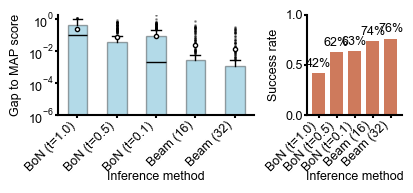

In [11]:
color_gap = "#2596be"
color_success = "#be4d25"

fig, (ax_gap, ax_success) = plt.subplots(
    1,
    2,
    figsize=(4.2, 2.),
    width_ratios=(2.4, 1.15),
)
gap_box = ax_gap.boxplot(
    gap_plot_data,
    tick_labels=display_names,
    showmeans=True,
    patch_artist=True,
    boxprops=dict(facecolor=color_gap, alpha=0.35, edgecolor="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black"),
    meanprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=3),
    flierprops=dict(marker=".", markersize=2, markerfacecolor="black", markeredgecolor="black", alpha=0.35),
)
ax_gap.set_ylabel("Gap to MAP score")
ax_gap.set_xlabel("Inference method", labelpad=-2)
ax_gap.set_yscale("log")
ax_gap.set_ylim(gap_plot_floor, max(gap_plot_floor * 10, max(np.max(gaps) for gaps in gap_plot_data) * 1.15))
for label in ax_gap.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment("right")

bars = ax_success.bar(display_names, success_rates, color=color_success, alpha=0.75, width=0.75)
ax_success.set_ylabel("Success rate")
ax_success.set_xlabel("Inference method", labelpad=-2)
ax_success.set_ylim(0.0, 1.0)
ax_success.set_yticks([0.0, 0.5, 1.0])
for label in ax_success.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment("right")
for bar, rate in zip(bars, success_rates):
    ax_success.text(
        bar.get_x() + bar.get_width() / 2,
        min(rate + 0.03, 0.98),
        f"{rate:.0%}",
        ha="center",
        va="bottom",
    )

for ax in (ax_gap, ax_success):
    ax.tick_params(length=2, pad=1)

plt.tight_layout(w_pad=0.8)
plt.savefig("map_estimation_gap_conv.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("map_estimation_gap_conv.svg", dpi=300, bbox_inches="tight", transparent=True)
